# NYC Crime Complaints and Arrests

## Questions

1. Where were 2025 crime complaints concentrated?
2. How did complaint patterns change by day, month, and season?
3. What percentage of 2025 arrest records involved each race and sex?
4. How did race arrest rates differ by borough?
5. How did arrest and complaint patterns compare across NYC neighborhoods?

In [3]:
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
complaints = pd.read_csv("complaints_2025.csv")
arrests = pd.read_csv("arrests_2025.csv")

complaints.shape, arrests.shape

((579561, 35), (278953, 19))

## Data cleaning

In [5]:
complaints["rpt_dt"] = pd.to_datetime(complaints["rpt_dt"])
arrests["arrest_date"] = pd.to_datetime(arrests["arrest_date"])

arrests["perp_sex"] = arrests["perp_sex"].replace({"M": "Male", "F": "Female", "(null)": "Unknown"})
arrests["perp_race"] = arrests["perp_race"].replace({"UNKNOWN": "Unknown", "(null)": "Unknown"})

In [6]:
print("Duplicate complaint IDs:", complaints.duplicated("cmplnt_num").sum())
print("Duplicate arrest IDs:", arrests.duplicated("arrest_key").sum())
print("Unknown sex records:", (arrests["perp_sex"] == "Unknown").sum())

Duplicate complaint IDs: 0
Duplicate arrest IDs: 0
Unknown sex records: 147237


In [7]:
complaints["month"] = complaints["rpt_dt"].dt.month
complaints["day_name"] = complaints["rpt_dt"].dt.day_name()
complaints["dayofweek"] = complaints["rpt_dt"].dt.dayofweek
complaints["hour"] = pd.to_numeric(complaints["cmplnt_fr_tm"].str.split(":").str[0], errors="coerce")

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

complaints["season"] = complaints["month"].map(season_map)
complaints["day_type"] = complaints["dayofweek"].map(lambda day: "Weekend" if day >= 5 else "Workday")


## Complaints by neighborhood


In [8]:
nta = gpd.read_file("nynta2020_26b/nynta2020.shp")
complaint_points = complaints.dropna(subset=["latitude", "longitude"]).copy()

complaint_points = gpd.GeoDataFrame(
    complaint_points,
    geometry=gpd.points_from_xy(complaint_points["longitude"], complaint_points["latitude"]),
    crs="EPSG:4326"
).to_crs(nta.crs)

In [9]:
complaint_nta = gpd.sjoin(
    complaint_points,
    nta[["NTA2020", "NTAName", "geometry"]],
    how="inner",
    predicate="within"
)

complaint_counts = complaint_nta.groupby("NTA2020")["cmplnt_num"].nunique()
complaint_counts = complaint_counts.reset_index(name="complaint_count")

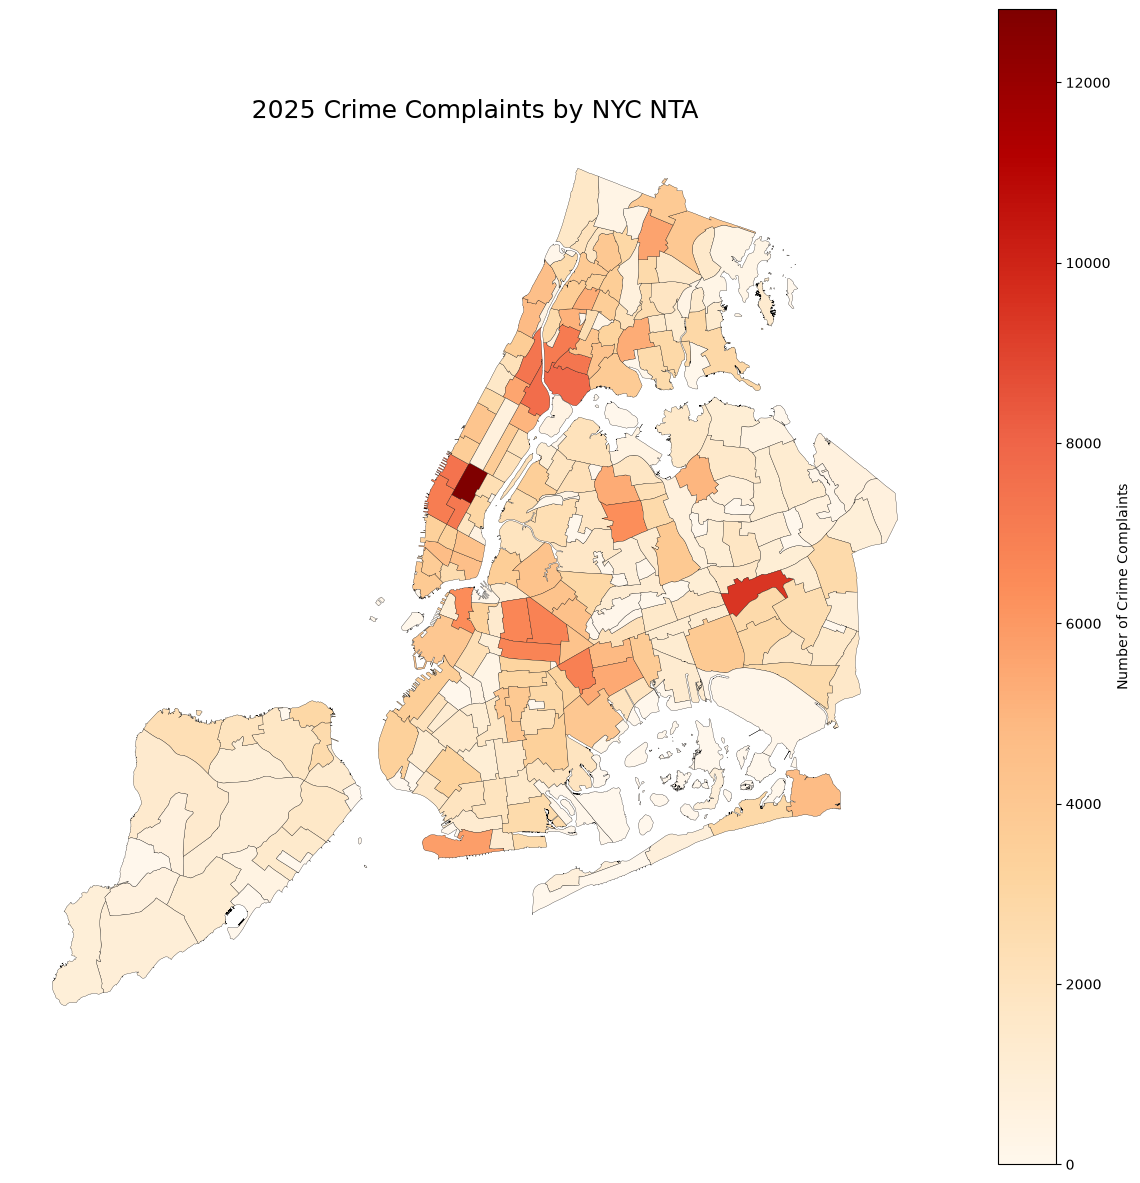

In [10]:
complaint_map = nta.merge(complaint_counts, on="NTA2020", how="left")
complaint_map["complaint_count"] = complaint_map["complaint_count"].fillna(0)

ax = complaint_map.plot(
    column="complaint_count",
    figsize=(15, 15),
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Number of Crime Complaints"}
)

ax.set_title("2025 Crime Complaints by NYC NTA", fontsize=18)
ax.axis("off")
plt.show()

## Complaints by day of week


In [11]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
complaints["day_name"] = pd.Categorical(complaints["day_name"], categories=days, ordered=True)

weekday = complaints.groupby("day_name", observed=False).size().reset_index(name="Complaints")
weekday

,day_name,Complaints
0,Monday,81326
1,Tuesday,87290
2,Wednesday,89869
3,Thursday,85556
4,Friday,85697
5,Saturday,77239
6,Sunday,72584


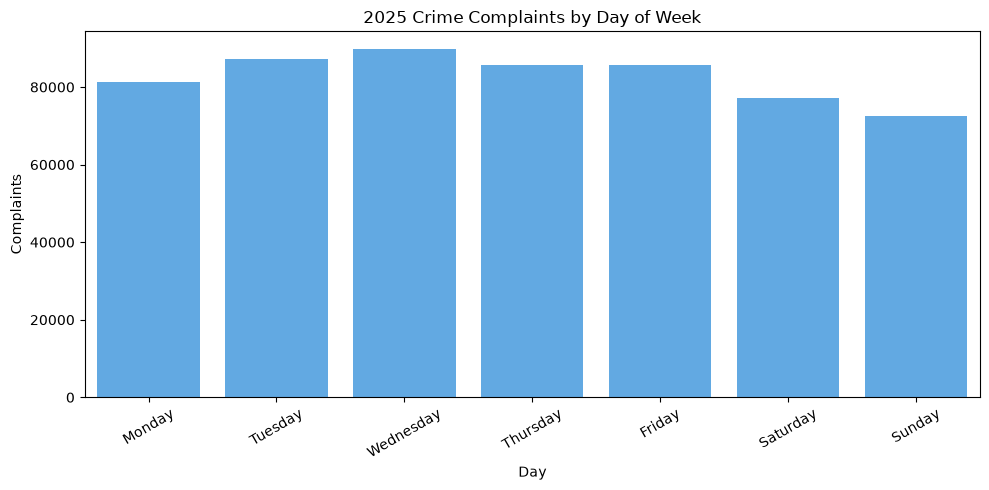

In [12]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=weekday, x="day_name", y="Complaints", color="#4DABF7")
ax.set(title="2025 Crime Complaints by Day of Week", xlabel="Day", ylabel="Complaints")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Monthly complaints by victim race

In [13]:
victim_race = complaints[
    complaints["vic_race"].notna()
    & ~complaints["vic_race"].isin(["(null)", "UNKNOWN"])
]

monthly_race = victim_race.groupby(["month", "vic_race"]).size().unstack(fill_value=0)
monthly_race

vic_race,AMERICAN INDIAN/ALASKAN NATIVE,ASIAN / PACIFIC ISLANDER,BLACK,BLACK HISPANIC,WHITE,WHITE HISPANIC
month,,,,,,
1,180,3123,10366,1823,5656,7024
2,195,2956,9477,1708,5183,6350
3,202,3480,11190,2206,6082,7807
4,246,3515,11449,2184,6240,7633
5,226,3766,11943,2382,6355,8299
6,256,3672,11788,2231,6434,8032
7,273,3952,12138,2484,6457,8216
8,273,4013,11675,2297,6482,8129
9,253,3968,11915,2224,6670,7869


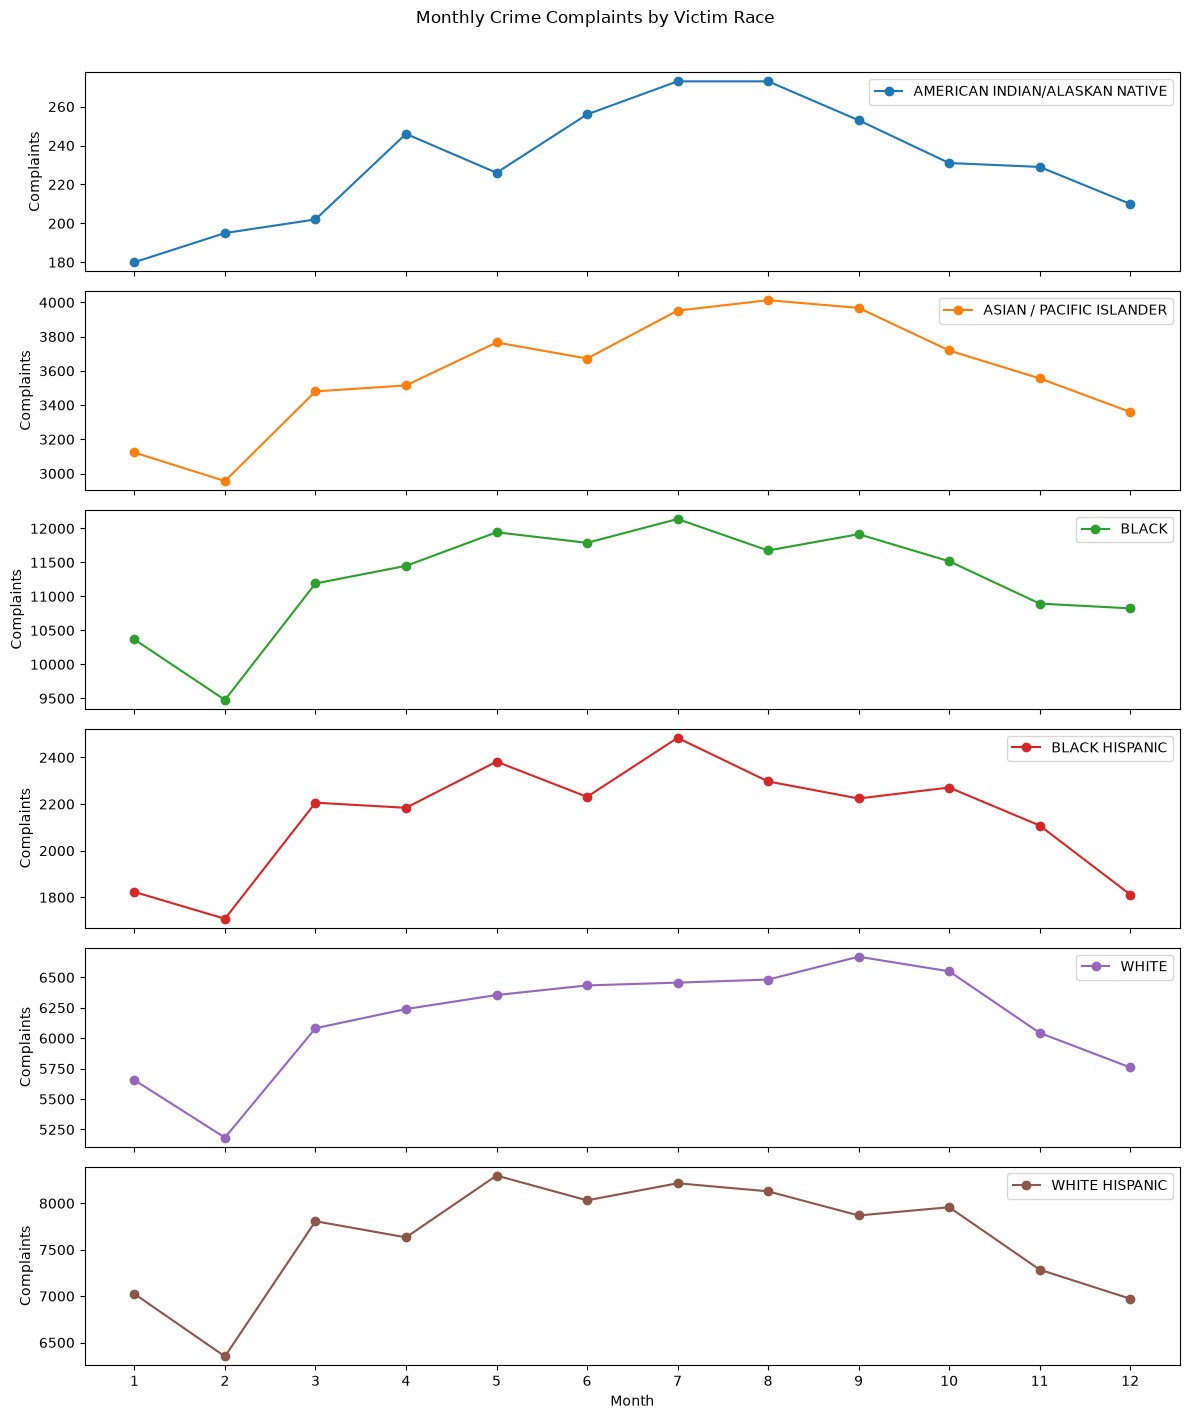

In [14]:
axes = monthly_race.plot(
    kind="line",
    marker="o",
    figsize=(12, 14),
    subplots=True,
    sharex=True
)

for ax in axes:
    ax.set(xlabel="Month", ylabel="Complaints", xticks=range(1, 13))

plt.suptitle("Monthly Crime Complaints by Victim Race", y=1.01)
plt.tight_layout()
plt.show()

## Monthly complaints by suspect race


In [15]:
cleaned_susp_race = complaints[
    complaints["susp_race"].notna()
    & (~complaints["susp_race"].isin(["(null)", "UNKNOWN"]))
]

monthly_susp_race = (
    cleaned_susp_race
    .groupby(["month", "susp_race"])
    .size()
    .unstack(fill_value=0)
)

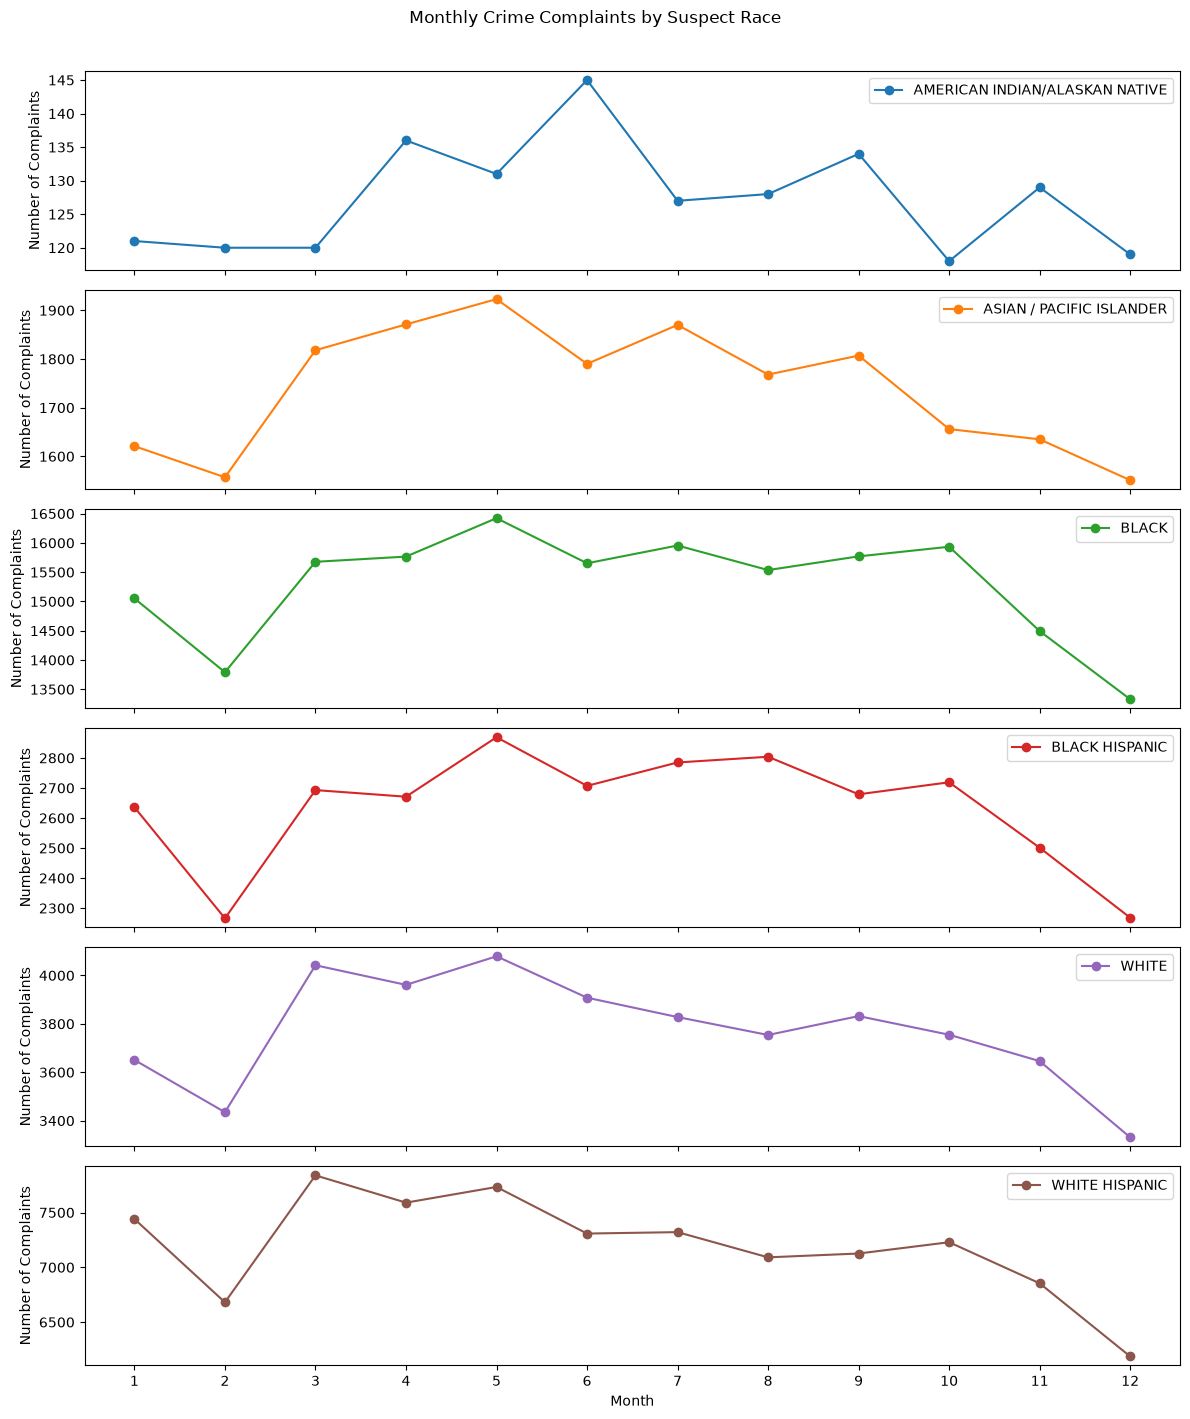

In [16]:
axes = monthly_susp_race.plot(
    kind="line",
    marker="o",
    figsize=(12, 14),
    subplots=True,
    sharex=True,
    legend=True
)

for ax in axes:
    ax.set_ylabel("Number of Complaints")
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")

plt.suptitle("Monthly Crime Complaints by Suspect Race", y=1.01)
plt.tight_layout()
plt.show()

## Complaints by season and hour

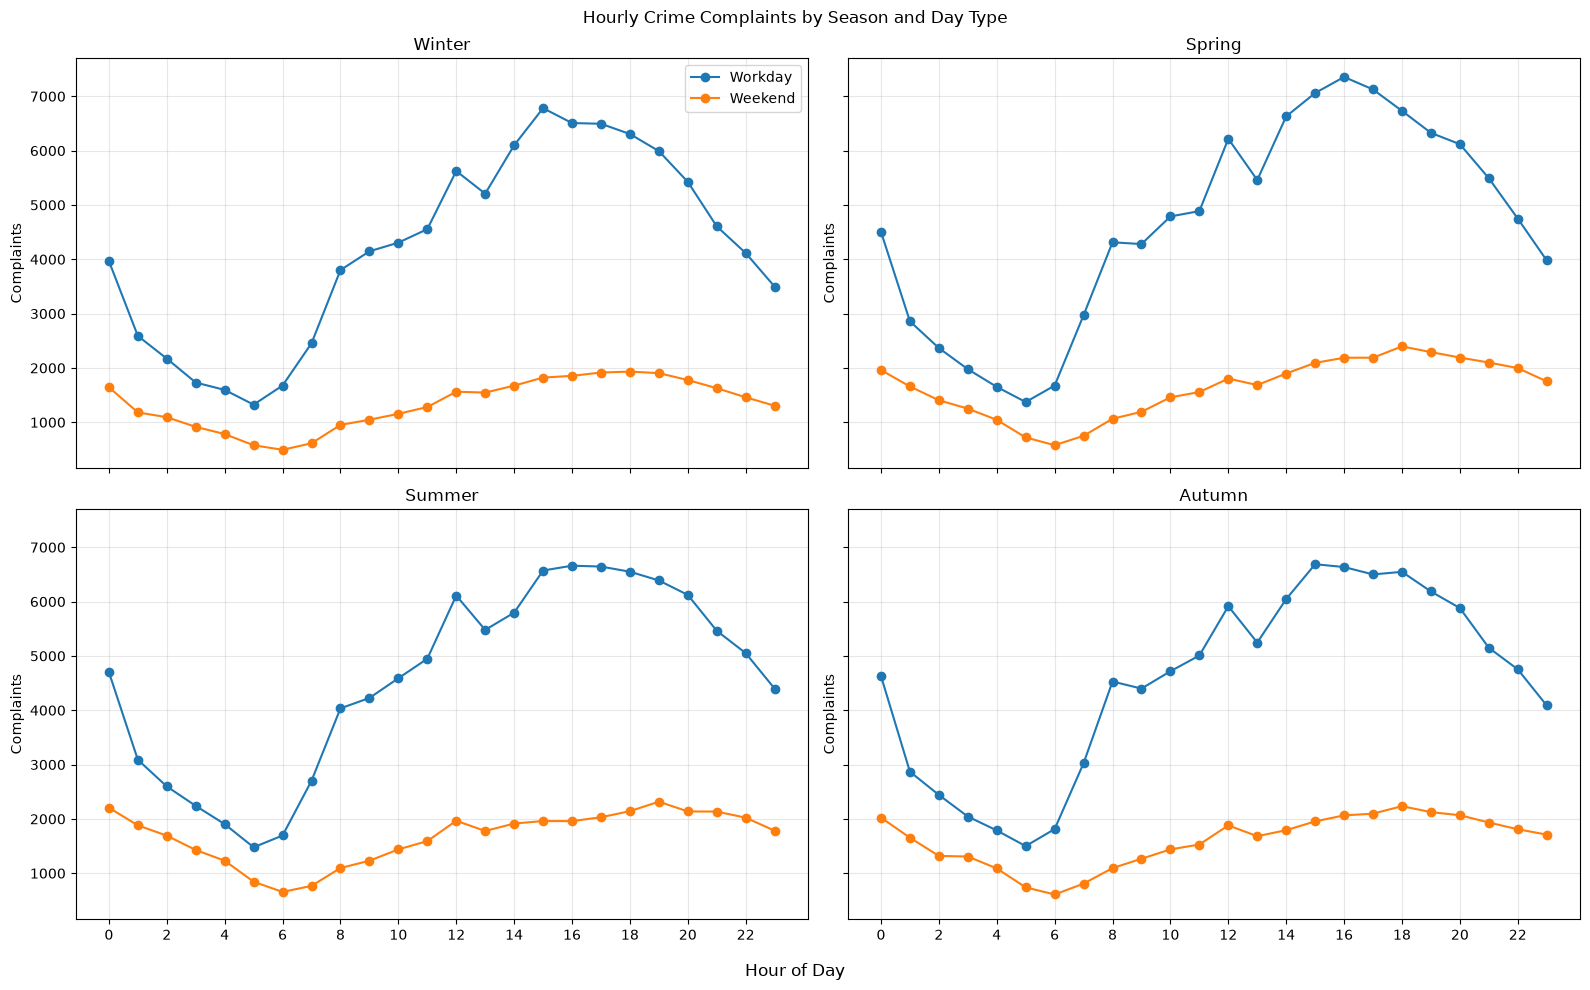

In [17]:
seasons = ["Winter", "Spring", "Summer", "Autumn"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

for index, season in enumerate(seasons):
    ax = axes[index // 2, index % 2]

    for day_type in ["Workday", "Weekend"]:
        hourly = complaints[
            (complaints["season"] == season)
            & (complaints["day_type"] == day_type)
        ].groupby("hour").size().reindex(range(24), fill_value=0)

        ax.plot(hourly.index, hourly.values, marker="o", label=day_type)

    ax.set(title=season, ylabel="Complaints", xticks=range(0, 24, 2))
    ax.grid(alpha=0.3)

axes[0, 0].legend()
fig.suptitle("Hourly Crime Complaints by Season and Day Type")
fig.supxlabel("Hour of Day")
plt.tight_layout()
plt.show()

# Arrest analysis

## Arrests by race



In [18]:
race = arrests.loc[arrests["perp_race"] != "Unknown", "perp_race"].str.title()
race_counts = race.value_counts().rename_axis("Race").reset_index(name="Count")
race_counts["Percentage"] = race_counts["Count"] / race_counts["Count"].sum() * 100
race_counts

,Race,Count,Percentage
0,Black,134262,48.295857
1,White Hispanic,69712,25.076349
2,White,29013,10.436368
3,Black Hispanic,27764,9.987086
4,Asian / Pacific Islander,16261,5.849302
5,American Indian/Alaskan Native,987,0.355037


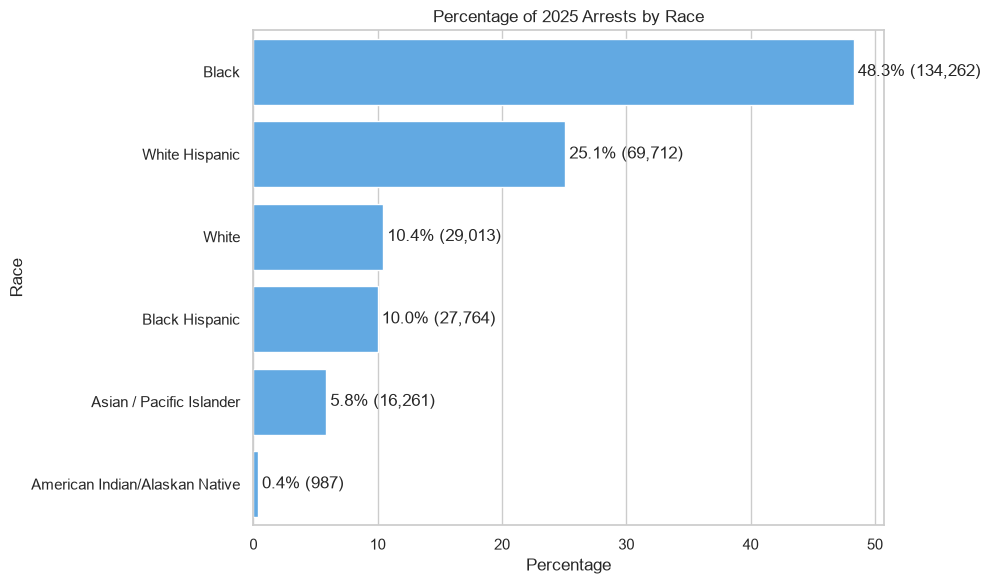

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=race_counts, x="Percentage", y="Race", color="#4DABF7")
labels = [f"{percent:.1f}% ({count:,})" for percent, count in zip(race_counts["Percentage"], race_counts["Count"])]
ax.bar_label(ax.containers[0], labels=labels, padding=3)
ax.set(title="Percentage of 2025 Arrests by Race", xlabel="Percentage", ylabel="Race")
plt.tight_layout()
plt.show()

## Arrests by sex
*Note: 147,237 arrest records (52.78%) had unknown sex and were excluded.*

In [20]:
sex = arrests.loc[arrests["perp_sex"] != "Unknown", "perp_sex"]
sex_counts = sex.value_counts().rename_axis("Sex").reset_index(name="Count")
sex_counts["Percentage"] = sex_counts["Count"] / sex_counts["Count"].sum() * 100
sex_counts

,Sex,Count,Percentage
0,Male,108874,82.658143
1,Female,22842,17.341857


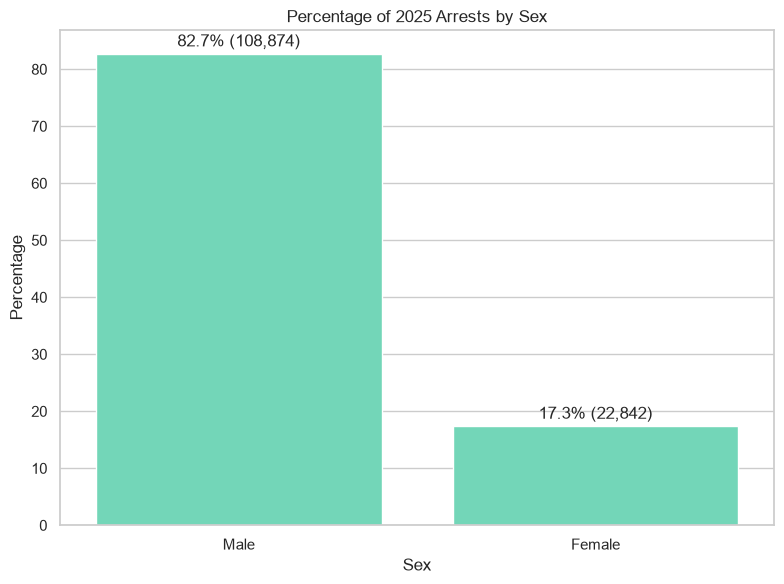

In [21]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=sex_counts, x="Sex", y="Percentage", color="#63E6BE")
labels = [f"{percent:.1f}% ({count:,})" for percent, count in zip(sex_counts["Percentage"], sex_counts["Count"])]
ax.bar_label(ax.containers[0], labels=labels, padding=3)
ax.set(title="Percentage of 2025 Arrests by Sex", xlabel="Sex", ylabel="Percentage")
plt.tight_layout()
plt.show()

## Race arrest rates by borough

Population gives context because boroughs and race groups differ in size. Census and NYPD race categories do not match perfectly.

In [22]:
census_url = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/counties/asrh/cc-est2025-alldata-36.csv"
census = pd.read_csv(census_url, encoding="latin-1")

borough_counties = [5, 47, 61, 81, 85]
borough_population = census.query("COUNTY in @borough_counties and YEAR == 7 and AGEGRP == 0").copy()

borough_names = {5: "Bronx", 47: "Brooklyn", 61: "Manhattan", 81: "Queens", 85: "Staten Island"}
borough_population["Borough"] = borough_population["COUNTY"].map(borough_names)

In [23]:
race_population = pd.DataFrame({"Borough": borough_population["Borough"]})
race_population["BLACK"] = borough_population["NHBA_MALE"] + borough_population["NHBA_FEMALE"]
race_population["WHITE"] = borough_population["NHWA_MALE"] + borough_population["NHWA_FEMALE"]
race_population["WHITE HISPANIC"] = borough_population["HWA_MALE"] + borough_population["HWA_FEMALE"]
race_population["BLACK HISPANIC"] = borough_population["HBA_MALE"] + borough_population["HBA_FEMALE"]
race_population["ASIAN / PACIFIC ISLANDER"] = borough_population["AA_MALE"] + borough_population["AA_FEMALE"] + borough_population["NA_MALE"] + borough_population["NA_FEMALE"]
race_population["AMERICAN INDIAN/ALASKAN NATIVE"] = borough_population["IA_MALE"] + borough_population["IA_FEMALE"]

race_population = race_population.melt(id_vars="Borough", var_name="Race", value_name="Population")

In [24]:
borough_codes = {"B": "Bronx", "K": "Brooklyn", "M": "Manhattan", "Q": "Queens", "S": "Staten Island"}
arrests["Borough"] = arrests["arrest_boro"].map(borough_codes)

race_arrests = arrests[arrests["perp_race"] != "Unknown"]
race_arrests = race_arrests.groupby(["Borough", "perp_race"]).size().reset_index(name="Arrests")
race_arrests.columns = ["Borough", "Race", "Arrests"]

race_rates = race_arrests.merge(race_population, on=["Borough", "Race"])
race_rates["Arrests per 100,000"] = race_rates["Arrests"] / race_rates["Population"] * 100000
race_rates

,Borough,Race,Arrests,Population,"Arrests per 100,000"
0,Bronx,AMERICAN INDIAN/ALASKAN NATIVE,150,73597,203.812655
1,Bronx,ASIAN / PACIFIC ISLANDER,982,86974,1129.073056
2,Bronx,BLACK,29758,389735,7635.444597
3,Bronx,BLACK HISPANIC,11409,246594,4626.633251
4,Bronx,WHITE,2116,120926,1749.830475
5,Bronx,WHITE HISPANIC,18161,407775,4453.681565
6,Brooklyn,AMERICAN INDIAN/ALASKAN NATIVE,225,53757,418.550142
7,Brooklyn,ASIAN / PACIFIC ISLANDER,4470,396290,1127.961846
8,Brooklyn,BLACK,45013,697069,6457.466908
9,Brooklyn,BLACK HISPANIC,4551,129039,3526.840723


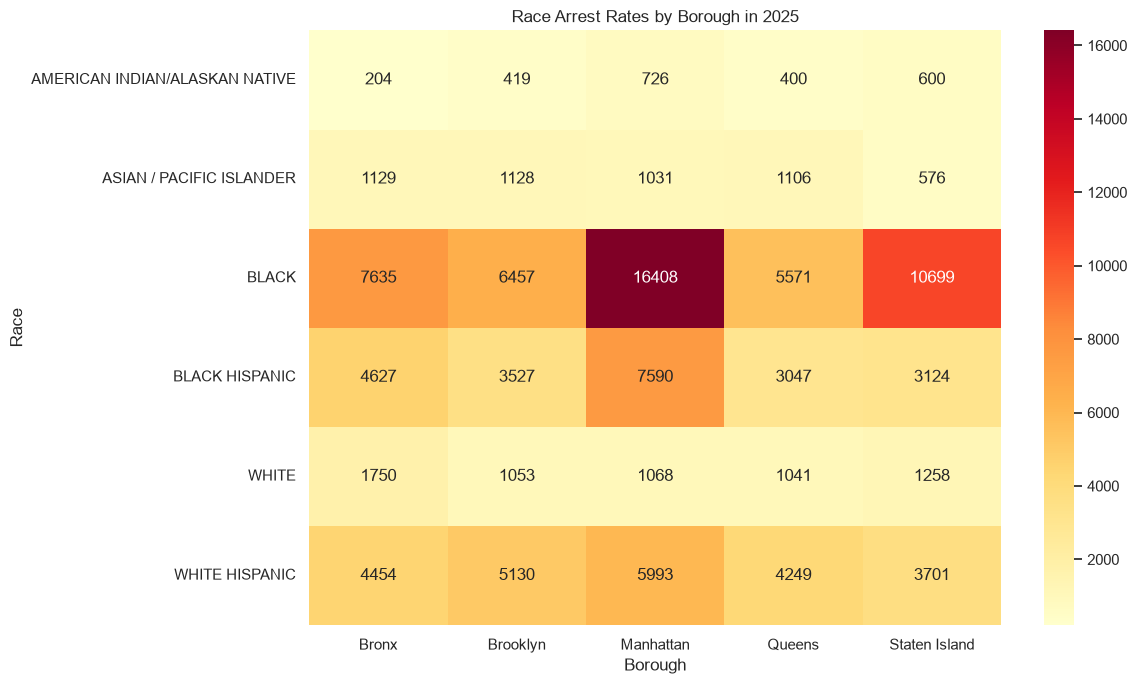

In [25]:
race_heatmap = race_rates.pivot(index="Race", columns="Borough", values="Arrests per 100,000")
race_heatmap = race_heatmap[["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]]

plt.figure(figsize=(12, 7))
sns.heatmap(race_heatmap, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Race Arrest Rates by Borough in 2025")
plt.xlabel("Borough")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

## Arrests by neighborhood

In [26]:
arrest_points = arrests.dropna(subset=["latitude", "longitude"]).copy()

arrest_points = gpd.GeoDataFrame(
    arrest_points,
    geometry=gpd.points_from_xy(arrest_points["longitude"], arrest_points["latitude"]),
    crs="EPSG:4326"
).to_crs(nta.crs)

arrest_nta = gpd.sjoin(
    arrest_points,
    nta[["NTA2020", "NTAName", "geometry"]],
    how="inner",
    predicate="within"
)

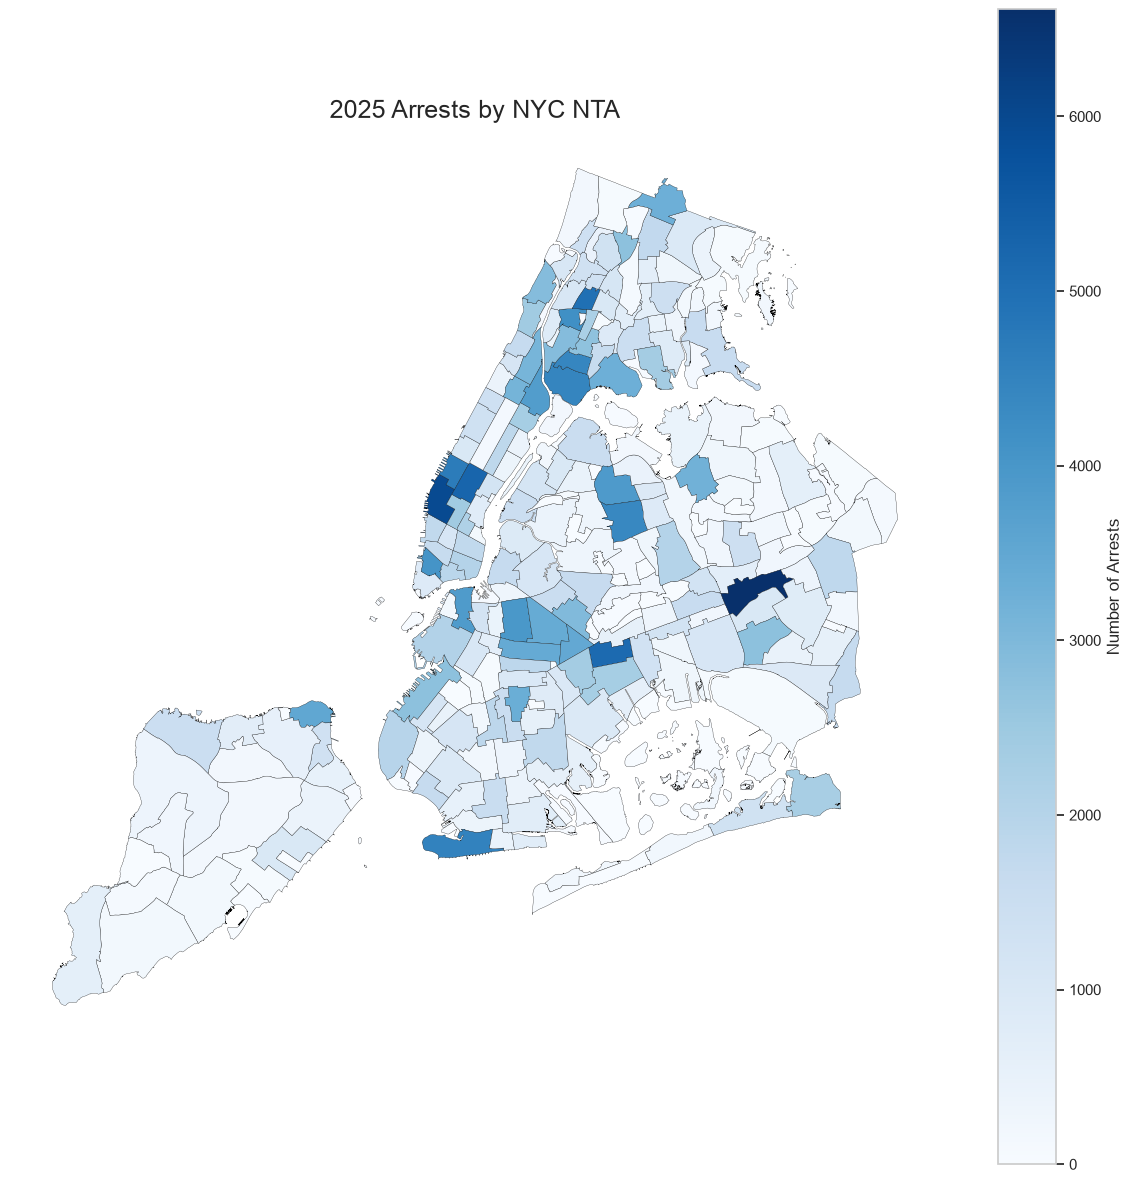

In [27]:
arrest_counts = arrest_nta.groupby("NTA2020")["arrest_key"].nunique()
arrest_counts = arrest_counts.reset_index(name="arrest_count")

arrest_map = nta.merge(arrest_counts, on="NTA2020", how="left")
arrest_map["arrest_count"] = arrest_map["arrest_count"].fillna(0)

ax = arrest_map.plot(
    column="arrest_count",
    figsize=(15, 15),
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Number of Arrests"}
)

ax.set_title("2025 Arrests by NYC NTA", fontsize=18)
ax.axis("off")
plt.show()

## Arrest share compared with complaint share

In [28]:
comparison = complaint_counts.merge(arrest_counts, on="NTA2020")
comparison["Complaint Share"] = comparison["complaint_count"] / comparison["complaint_count"].sum() * 100
comparison["Arrest Share"] = comparison["arrest_count"] / comparison["arrest_count"].sum() * 100
comparison["Difference"] = comparison["Arrest Share"] - comparison["Complaint Share"]

correlation = comparison[["complaint_count", "arrest_count"]].corr().iloc[0, 1]
comparison_map = nta.merge(comparison, on="NTA2020")

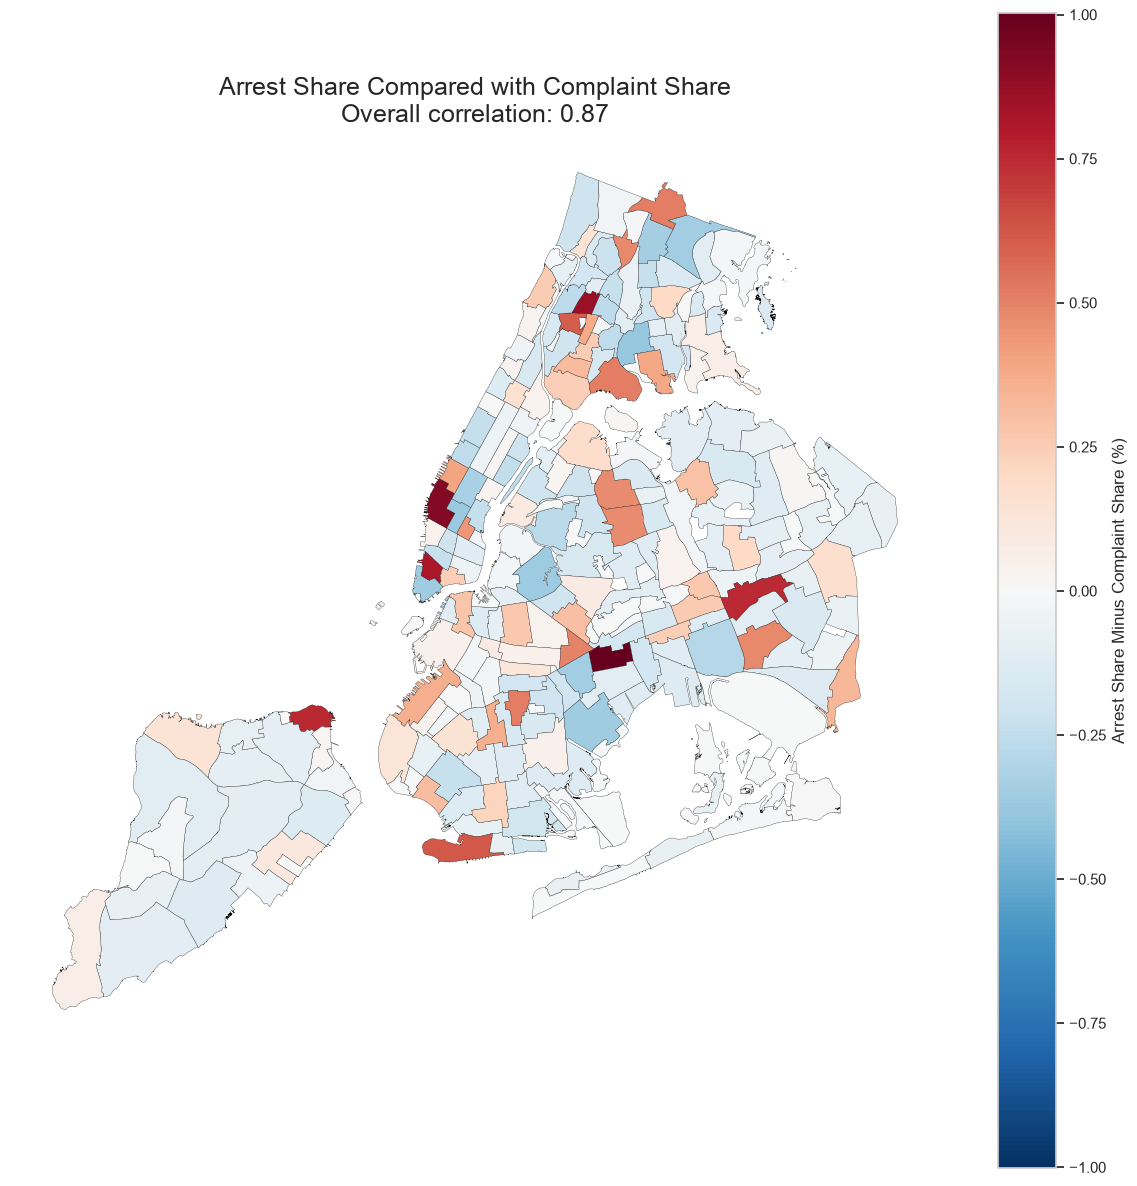

In [29]:
limit = comparison["Difference"].abs().max()
high = comparison_map.nlargest(5, "Difference")
low = comparison_map.nsmallest(5, "Difference")
labels = pd.concat([high, low])

ax = comparison_map.plot(
    column="Difference",
    figsize=(15, 15),
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Arrest Share Minus Complaint Share (%)"}
)

ax.set_title(f"Arrest Share Compared with Complaint Share\nOverall correlation: {correlation:.2f}", fontsize=18)
ax.axis("off")
plt.show()

In [30]:
labels[["NTAName", "Difference"]].sort_values("Difference", ascending=False)

,NTAName,Difference
15,East New York (North),1.002096
122,Chelsea-Hudson Yards,0.921844
80,Mount Hope,0.867249
114,Tribeca-Civic Center,0.818024
227,St. George-New Brighton,0.759325
113,Financial District-Battery Park City,-0.354082
60,Canarsie,-0.356198
3,East Williamsburg,-0.362320
124,Midtown South-Flatiron-Union Square,-0.374317
91,Soundview-Bruckner-Bronx River,-0.383363


## Machine learning


R²: 0.76


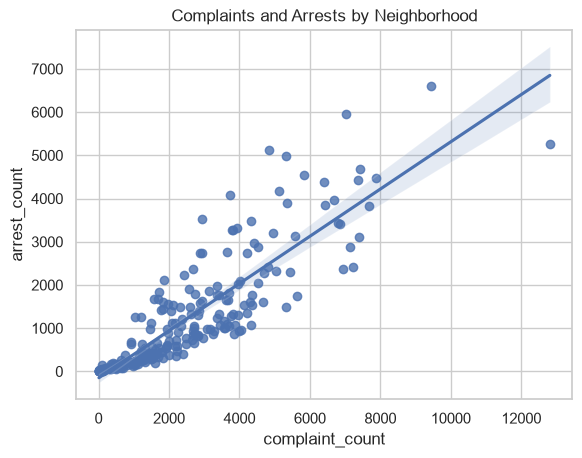

In [ ]:
X = comparison[["complaint_count"]]
y = comparison["arrest_count"]
model = LinearRegression()
model.fit(X, y)
print(f"R²: {model.score(X, y):.2f}")
sns.regplot(data=comparison, x="complaint_count", y="arrest_count")
plt.title("Complaints and Arrests by Neighborhood")
plt.show()

# Final insight

Complaint and arrest totals across neighborhoods have a strong correlation of about 0.87, but this does not mean complaints led to arrests. The datasets do not share an ID connecting a complaint to an arrest, so we cannot calculate a true arrest or clearance rate.

The demographic data also has a major quality problem: 147,237 arrest records (52.78%) did not report sex. The male and female percentages only describe records with a known sex and may not represent all 2025 arrests.

## Recommendation

NYC should improve missing demographic fields and publish a safe shared identifier or outcome field connecting complaints with arrests. This would allow accurate clearance-rate analysis and help the city investigate neighborhoods where arrest and complaint patterns differ before changing enforcement or community resources.

## AI use disclosure

We used ChatGPT and Codex to help troubleshoot the notebook environment, organize and revise Python code, and improve the visualizations. We reviewed the code, ran the analysis, and checked the interpretations.